In [1]:
#!git clone https://github.com/andreghl/EMTH0001.git

# Installing the remaining packages quietly
#!pip install -q -r EMTH0001/requirements.txt

In [2]:
# Run the Python script
#!python EMTH0001/src/main.py

In [3]:
import torch

from src.utils.data import generate
from src.data.coalitions import CoalitionNN


_Dm, A, C, v, Sh, n = generate(3, 9)
Dm = torch.from_numpy(_Dm[:, 1:])
C = torch.from_numpy(C)

xDm = Dm.unsqueeze(1).repeat(1, 8, 1, 1)
xDm = xDm.reshape(-1, 12 * 4)
xC = C.reshape(-1, 3)

model = CoalitionNN()
model.load_state_dict(torch.load("src/data/coalitions.pth"))
model.eval()

with torch.no_grad():
    outputs = model(xDm.float(), xC.float())

print('predicted: ', outputs.t())
print('actual: ', v)

#TODO:
#- capture gradients -> helps identify problems
#- change init (need seeding)
#- changing the seed can improve the results (need at least 3 diff seeds) -> find literature to put in thesis
#- make plots of the output to compare predicted to actual

predicted:  tensor([[0.0201, 0.0183, 0.0197, 0.0175, 0.4356, 0.4369, 0.4441, 1.5020]])
actual:  [0.     0.     0.     0.     0.5517 0.5391 0.8865 2.4324]


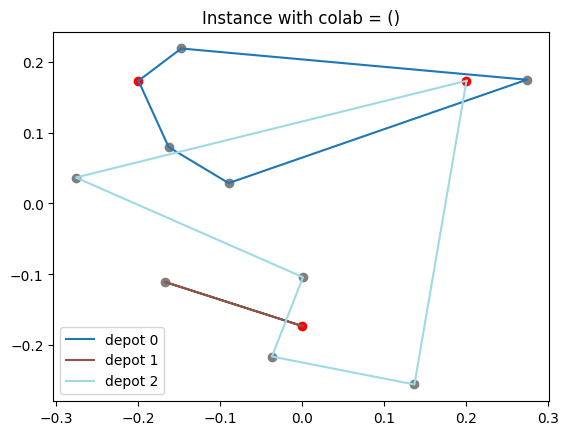

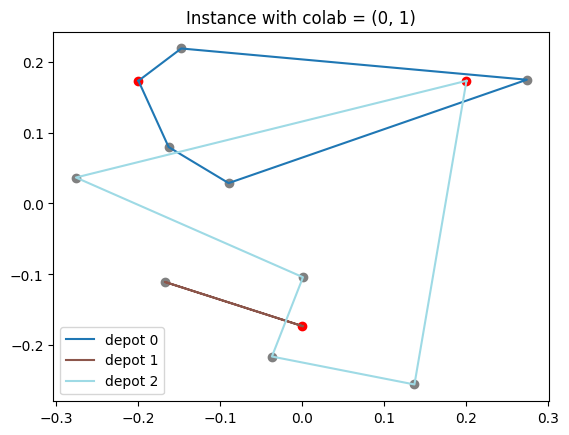

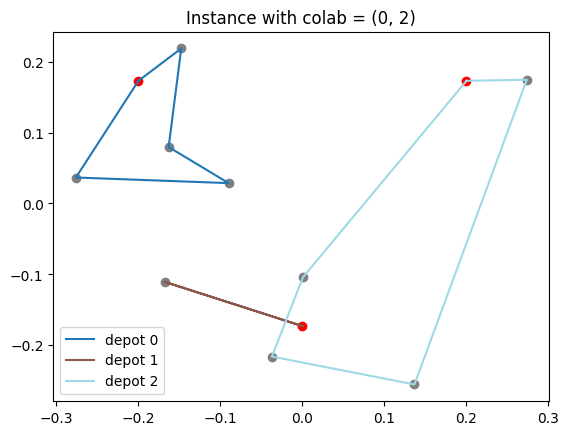

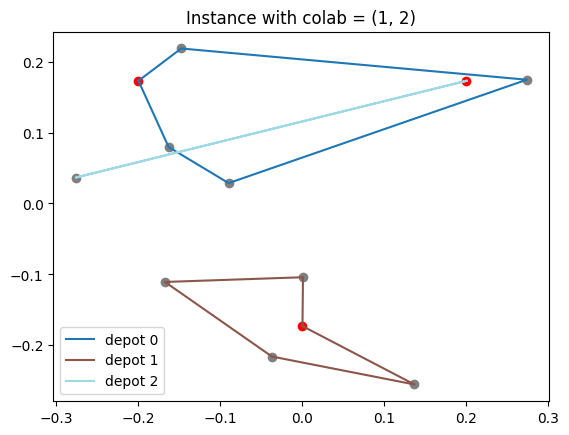

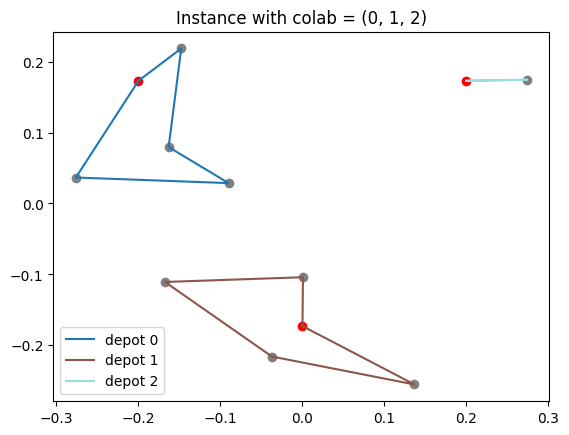

In [4]:
from src.utils.data import generate

n_depots = 3
n_customers = 9
dm, assignments, coalitions, v, _shapley, _nucleolus = generate(n_depots, n_customers, plots = True)

In [5]:
print(v)

[0.     0.     0.     0.     0.     0.8062 0.1596 1.4367]
